# Nuclear Energy: Clean Energy Investment or Financial Risk?

**Question:** Based on the labeled article dataset, is nuclear energy more often framed as a worthwhile clean-energy investment or as a potential financial risk?

The dataset contains newspaper records labeled `worthwhile`, `risk`, or `unrelated`. I remove unrelated articles for the main comparison and analyze the remaining labels by overall count, year, publication, and title keywords.

In [8]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

csv_path = Path('project_dataset.csv')

raw = pd.read_csv(csv_path)
raw.head()

,Analysis,GOID,Title,Date,Source Type,Authors,Publication ID,Publication Title,Publisher City,Publisher Province,ISBN,URL
0,worthwhile,3330892884,Need innovative solutions to finance nuclear p...,2026-04-18,Newspapers,"['Samant, Shilpa']",29263,The Economic Times,New Delhi,NaN,NaN,https://www.proquest.com/docview/3330892884
1,unrelated,3331228362,Phoenix from Flames: How Cult of Miliband Grew...,2026-04-19,Newspapers,NaN,32356,The Sunday Telegraph,Tonbridge,NaN,NaN,https://www.proquest.com/docview/3331228362
2,unrelated,3331286622,The cult of Ed Miliband,2026-04-19,Newspapers,"['Oliver, Matt']",1986348,Telegraph.co.uk,London,NaN,NaN,https://www.proquest.com/docview/3331286622
3,worthwhile,3331328174,Strait truth: India must hasten energy transition,2026-04-19,Newspapers,NaN,29618,The Hindustan Times,New Delhi,NaN,NaN,https://www.proquest.com/docview/3331328174
4,unrelated,3331457998,"Korea, India to set up 1st ministerial-level c...",2026-04-20,Newspapers,"['Whan-woo, Yi']",2046300,The Korea Times,Seoul,NaN,NaN,https://www.proquest.com/docview/3331457998


## 1. Clean the Data

Only a few fields are needed: the article label, date, title, and publication.

In [9]:
df = raw.copy()
df['analysis'] = df['Analysis'].str.lower().str.strip()
df['date'] = pd.to_datetime(df['Date'], errors='coerce')
df['year'] = df['date'].dt.year
df['publication'] = df['Publication Title'].str.strip()

relevant = df[df['analysis'].isin(['worthwhile', 'risk'])].copy()

overview = pd.Series({
    'total articles': len(df),
    'relevant articles': len(relevant),
    'unrelated articles removed': (df['analysis'] == 'unrelated').sum(),
    'date range': f"{df['date'].min().date()} to {df['date'].max().date()}"  # is this neccessary?
})

display(overview)
display(df['analysis'].value_counts())

total articles                                    4037
relevant articles                                 3016
unrelated articles removed                        1021
date range                    2021-05-07 to 2026-05-05
dtype: object

analysis
worthwhile    1588
risk          1428
unrelated     1021
Name: count, dtype: int64

## 2. Overall Result

The first comparison asks whether the relevant articles lean more toward `worthwhile` or `risk`.

Worthwhile share among relevant articles: 52.7%


analysis
worthwhile    1588
risk          1428
Name: count, dtype: int64

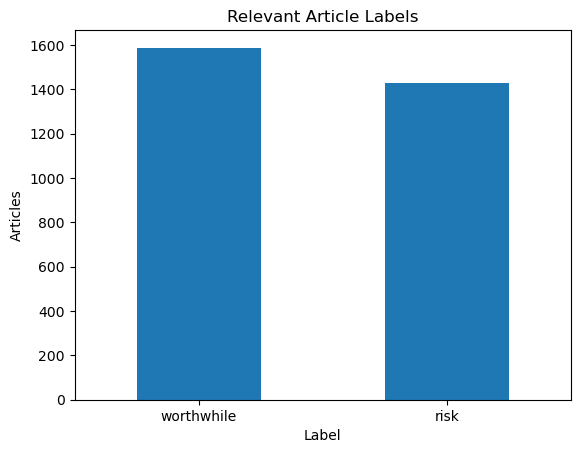

In [10]:
counts = relevant['analysis'].value_counts()
worthwhile_share = counts['worthwhile'] / counts.sum()

print(f"Worthwhile share among relevant articles: {worthwhile_share:.1%}")
display(counts)

counts.plot(kind='bar', title='Relevant Article Labels')
plt.xlabel('Label')
plt.ylabel('Articles')
plt.xticks(rotation=0)
plt.show()

**Finding:** Nuclear energy is framed slightly more often as worthwhile than risky. The margin is positive, but close enough that financial risk remains an important part of the story.

## 3. Trend by Year

The investment case is stronger if the positive view is consistent over time.

analysis,risk,worthwhile,worthwhile_share
year,,,
2021,118,150,0.559701
2022,243,277,0.532692
2023,214,269,0.556936
2024,468,354,0.430657
2025,322,388,0.546479
2026,63,150,0.704225


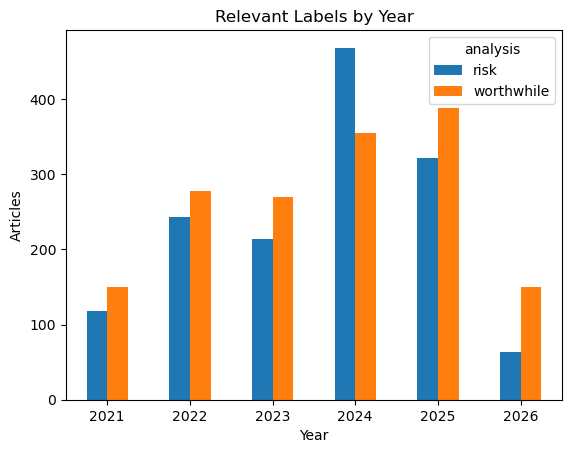

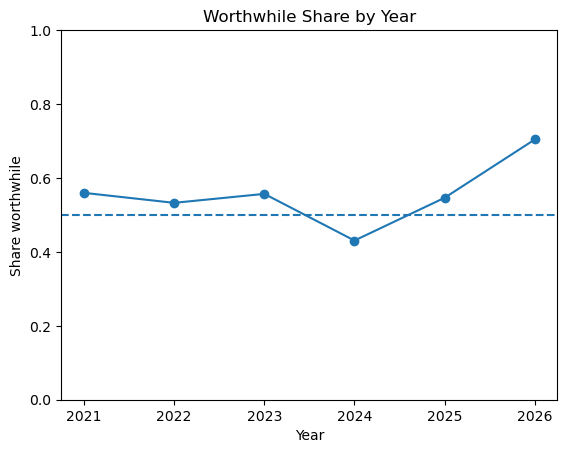

In [11]:
yearly = pd.crosstab(relevant['year'], relevant['analysis'])
yearly['worthwhile_share'] = yearly['worthwhile'] / (yearly['worthwhile'] + yearly['risk'])
display(yearly)

yearly[['risk', 'worthwhile']].plot(kind='bar', title='Relevant Labels by Year')
plt.xlabel('Year')
plt.ylabel('Articles')
plt.xticks(rotation=0)
plt.show()

yearly['worthwhile_share'].plot(marker='o', title='Worthwhile Share by Year')
plt.axhline(0.5, linestyle='--')
plt.xlabel('Year')
plt.ylabel('Share worthwhile')
plt.ylim(0, 1)
plt.show()

**Finding:** The yearly pattern is mixed. Overall view towards Nuclear power was more positive in 2021-2023, turned risk heavy in 2024, and became more positive again in 2025 and the partial 2026 data. This suggests nuclear investment sentiment is sensitive to changing market and policy conditions.

## 4. Publication Differences

Publication results show whether the overall conclusion depends on where the article appeared.

analysis,risk,worthwhile,total,worthwhile_share
publication,,,,
Asia News Monitor,46,199,245,0.812245
The Australian,112,75,187,0.401070
Telegraph.co.uk,103,80,183,0.437158
The Australian (Online),104,70,174,0.402299
The Australian Financial Review,108,41,149,0.275168
The Daily Telegraph,63,62,125,0.496000
Weekend Australian,35,35,70,0.500000
Yerepouni Daily News,26,34,60,0.566667
Express (Online),35,17,52,0.326923


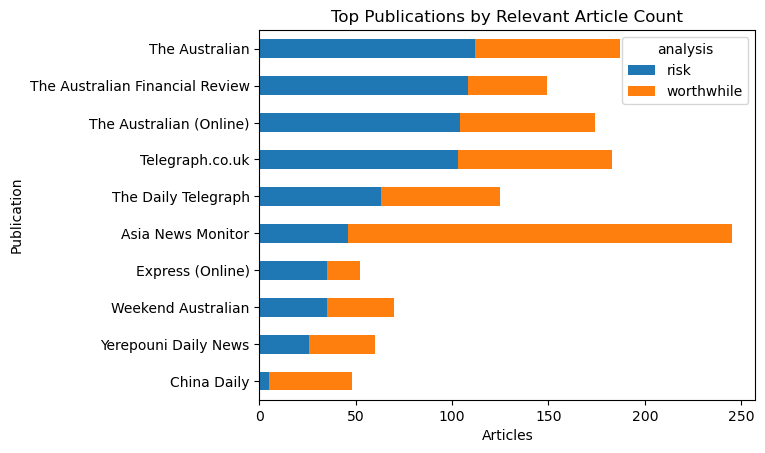

In [12]:
publication_summary = (
    relevant.groupby('publication')['analysis']
    .value_counts()
    .unstack(fill_value=0)
)
publication_summary['total'] = publication_summary['worthwhile'] + publication_summary['risk']
publication_summary['worthwhile_share'] = publication_summary['worthwhile'] / publication_summary['total']
publication_summary = publication_summary.sort_values('total', ascending=False)

display(publication_summary.head(15))

publication_summary.head(10)[['risk', 'worthwhile']].sort_values('risk').plot(
    kind='barh', stacked=True, title='Top Publications by Relevant Article Count'
)
plt.xlabel('Articles')
plt.ylabel('Publication')
plt.show()

In [13]:
large_publications = publication_summary[publication_summary['total'] >= 25]

print('Most worthwhile leaning publications:')
display(large_publications.sort_values('worthwhile_share', ascending=False).head(8))

print('Most risk leaning publications:')
display(large_publications.sort_values('worthwhile_share').head(8))

Most worthwhile leaning publications:


analysis,risk,worthwhile,total,worthwhile_share
publication,,,,
Financial Express,3,33,36,0.916667
China Daily,5,43,48,0.895833
Asia News Monitor,46,199,245,0.812245
The Business Times,7,23,30,0.766667
Mint,10,30,40,0.750000
Barron's (Online),8,23,31,0.741935
Daily Mail,9,18,27,0.666667
Mail on Sunday,10,18,28,0.642857


Most risk leaning publications:


analysis,risk,worthwhile,total,worthwhile_share
publication,,,,
EveningReport.nz,26,0,26,0.000000
The Age,35,4,39,0.102564
Sydney Morning Herald,32,4,36,0.111111
The Australian Financial Review,108,41,149,0.275168
The New York Times,19,8,27,0.296296
Express (Online),35,17,52,0.326923
The Sunday Telegraph,20,10,30,0.333333
Toronto Star (2010-),17,11,28,0.392857


**Finding:** The result varies strongly by publication. Some outlets, such as `Asia News Monitor`, `China Daily`, `Financial Express`, and `Mint`, lean toward the worthwhile framing. Others, including `The Australian Financial Review`, `The Age`, `Sydney Morning Herald`, and `EveningReport.nz`, lean much more toward risk.

## 5. Title Keyword Themes

Title keywords give a quick explanation of what types of nuclear stories are positive or negative.

,theme,articles,worthwhile,risk,worthwhile_share
2,clean/climate/security,743,407,336,0.547779
4,policy/government,303,165,138,0.544554
1,risk/cost pressure,298,96,202,0.322148
0,investment/finance,289,195,94,0.674740
3,small modular reactors,45,38,7,0.844444


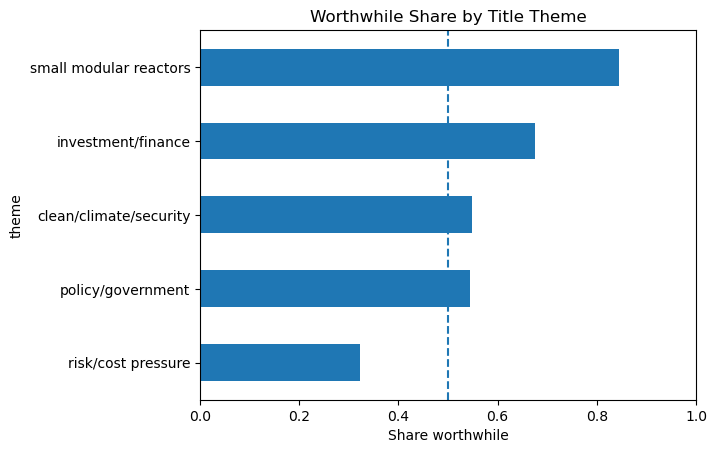

In [14]:
keyword_groups = {
    'investment/finance': ['invest', 'financ', 'fund', 'capital', 'market', 'business', 'private', 'partnership'],
    'risk/cost pressure': ['risk', 'cost', 'delay', 'overrun', 'price', 'expensive', 'debt', 'tax', 'waste', 'concern'],
    'clean/climate/security': ['clean', 'green', 'climate', 'carbon', 'emission', 'net zero', 'transition', 'security'],
    'small modular reactors': ['smr', 'small modular', 'modular reactor'],
    'policy/government': ['government', 'policy', 'minister', 'bill', 'regulat', 'approval', 'subsid']
}

rows = []
for theme, words in keyword_groups.items():
    pattern = '|'.join(words)
    subset = relevant[relevant['Title'].str.lower().str.contains(pattern, na=False, regex=True)]
    rows.append({
        'theme': theme,
        'articles': len(subset),
        'worthwhile': (subset['analysis'] == 'worthwhile').sum(),
        'risk': (subset['analysis'] == 'risk').sum(),
        'worthwhile_share': (subset['analysis'] == 'worthwhile').mean()
    })

keyword_summary = pd.DataFrame(rows).sort_values('articles', ascending=False)
display(keyword_summary)

keyword_summary.set_index('theme')['worthwhile_share'].sort_values().plot(
    kind='barh', title='Worthwhile Share by Title Theme'
)
plt.axvline(0.5, linestyle='--')
plt.xlabel('Share worthwhile')
plt.xlim(0, 1)
plt.show()

**Finding:** Small modular reactor titles are strongly worthwhile leaning, and investment/finance and policy themes are also more positive than negative. Titles about cost pressure, delays, debt, taxes, waste, and similar risks are much more negative. Clean energy language alone is not enough to remove financial concern.

## Conclusion

Nuclear energy appears to be a worthwhile but financially risky clean energy investment in this dataset.

The positive case is that relevant articles are slightly more likely to label nuclear as `worthwhile` than `risk`, and the strongest positive themes involve financing, policy support, energy security, and small modular reactors. That suggests nuclear is viewed as a serious clean-energy investment option.

The risk case is also substantial. The overall margin is narrow, 2024 was risk dominant, and cost related titles lean strongly negative. Nuclear investment therefore looks most attractive when projects have credible financing, government support, and clear decarbonization or energy security benefits. It looks financially risky when high costs, long timelines, electricity price impacts, waste, or policy uncertainty dominate the story.